In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../figures", exist_ok=True)

In [2]:
df = pd.read_csv("../results/results_summary.csv")

# Pivot so each row is a unique postprocessing config with both mAP values
id_cols = ["model", "cell_type", "agg", "fs", "norm1", "norm2"]
wide = df.pivot_table(index=id_cols, columns="task", values="mAP").reset_index()
wide.columns.name = None
wide = wide.rename(columns={"replicate": "replicate_mAP", "moa": "moa_mAP"})

# Build a label for the postprocessing pipeline
wide["pipeline"] = (
    "agg=" + wide["agg"].astype(str)
    + " fs=" + wide["fs"].astype(str)
    + " " + wide["norm1"].astype(str)
    + "/" + wide["norm2"].astype(str)
)

wide.head()

,model,cell_type,agg,fs,norm1,norm2,moa_mAP,replicate_mAP,pipeline
0,cell_dino,A549,mean,0,PCA,mad_robustize,0.173755,0.437807,agg=mean fs=0 PCA/mad_robustize
1,cell_dino,A549,mean,0,PCA,standardize,0.168679,0.428618,agg=mean fs=0 PCA/standardize
2,cell_dino,A549,mean,0,PCAcor,mad_robustize,0.173241,0.435069,agg=mean fs=0 PCAcor/mad_robustize
3,cell_dino,A549,mean,0,PCAcor,standardize,0.165724,0.423777,agg=mean fs=0 PCAcor/standardize
4,cell_dino,A549,mean,0,ZCA,mad_robustize,0.161597,0.383635,agg=mean fs=0 ZCA/mad_robustize


In [3]:
MODEL_ORDER = [
    "cellprofiler", "deepprofiler",
    "dino", "dino_masked",
    "subcell_mae", "subcell_mae_masked",
    "subcell_vit", "subcell_vit_masked",
    "cell_dino", "cell_dino_masked",
    "cell_dino_avgpool", "cell_dino_avgpool_masked",
]


def pareto_mask(x, y):
    """Return boolean mask for points on the Pareto frontier (maximize both)."""
    is_pareto = np.ones(len(x), dtype=bool)
    for i in range(len(x)):
        for j in range(len(x)):
            if i != j and x[j] >= x[i] and y[j] >= y[i] and (x[j] > x[i] or y[j] > y[i]):
                is_pareto[i] = False
                break
    return is_pareto

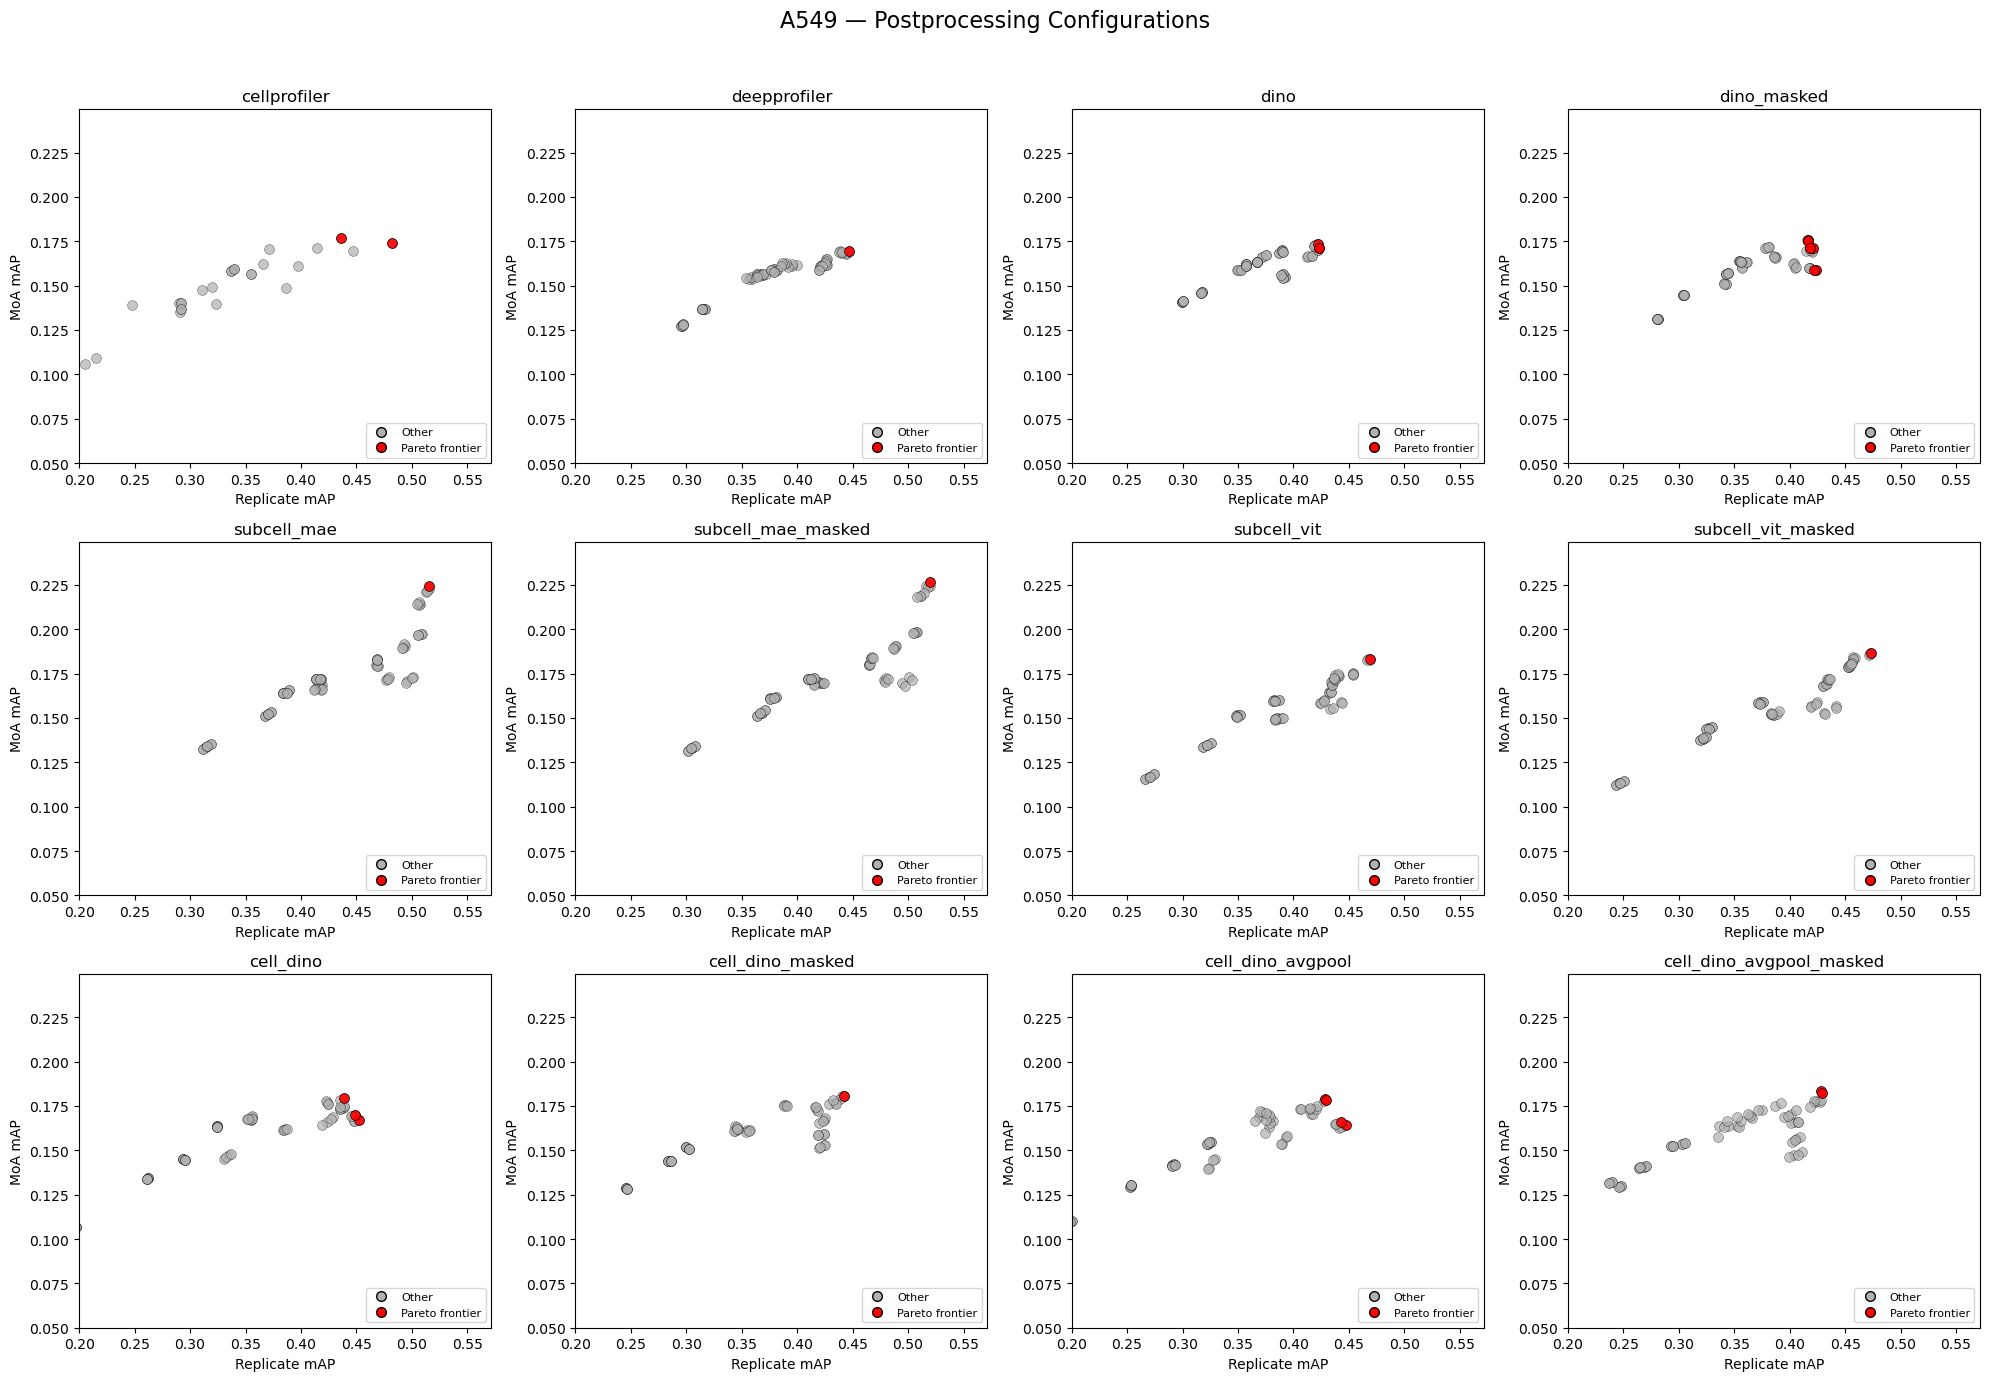

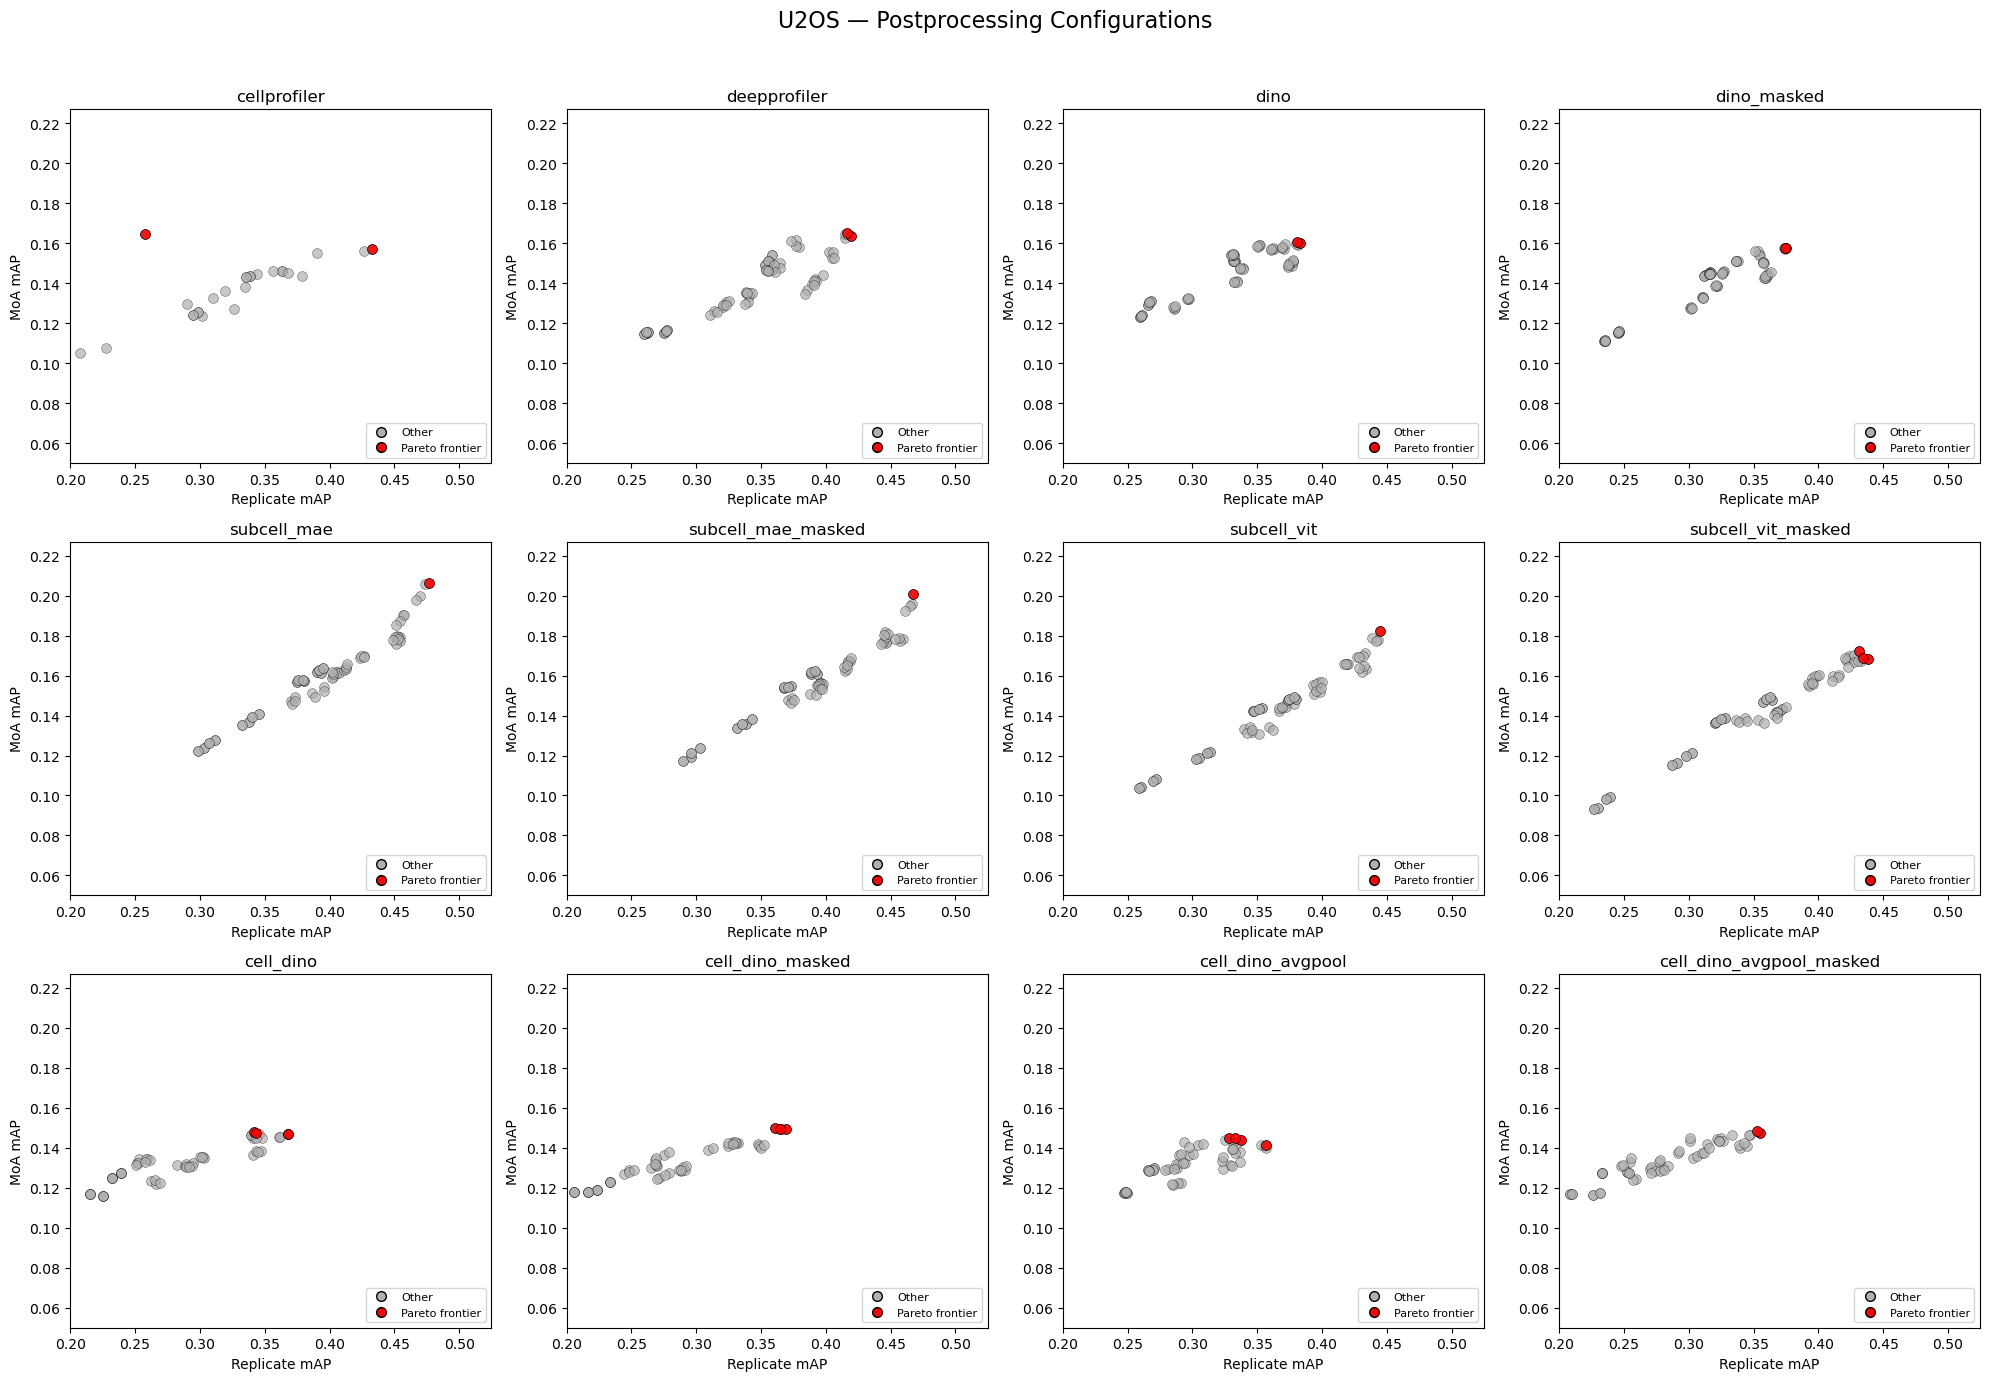

In [4]:
from matplotlib.lines import Line2D

for cell_type in sorted(wide["cell_type"].unique()):
    ct_df = wide[wide["cell_type"] == cell_type]
    models_present = [m for m in MODEL_ORDER if m in ct_df["model"].unique()]
    n = len(models_present)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                             squeeze=False)
    fig.suptitle(f"{cell_type} — Postprocessing Configurations", fontsize=16, y=1.02)

    # Shared axis limits across all subplots for this cell type
    x_max = ct_df["replicate_mAP"].max() * 1.1
    y_max = ct_df["moa_mAP"].max() * 1.1

    for idx, model in enumerate(models_present):
        ax = axes[idx // ncols, idx % ncols]
        mdf = ct_df[ct_df["model"] == model].reset_index(drop=True)

        x = mdf["replicate_mAP"].values
        y = mdf["moa_mAP"].values
        on_front = pareto_mask(x, y)

        # All points in gray
        ax.scatter(x, y, c="#b0b0b0", alpha=0.7, edgecolors="k",
                   linewidths=0.3, s=50, zorder=1)
        # Pareto frontier points in red
        ax.scatter(x[on_front], y[on_front], c="red", alpha=0.9,
                   edgecolors="k", linewidths=0.5, s=50, zorder=2)

        ax.set_title(model, fontsize=12)
        ax.set_xlabel("Replicate mAP")
        ax.set_ylabel("MoA mAP")
        ax.set_xlim(0.2, x_max)
        ax.set_ylim(0.05, y_max)

        legend_handles = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#b0b0b0",
                   markeredgecolor="k", markersize=7, label="Other"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
                   markeredgecolor="k", markersize=7, label="Pareto frontier"),
        ]
        ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

    # Hide unused axes
    for idx in range(n, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    fig.tight_layout()
    fig.savefig(f"../figures/pareto_frontiers_{cell_type}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
# Collect all Pareto frontier rows
pareto_rows = []
for (cell_type, model), grp in wide.groupby(["cell_type", "model"]):
    x = grp["replicate_mAP"].values
    y = grp["moa_mAP"].values
    mask = pareto_mask(x, y)
    pareto_rows.append(grp[mask])

pareto_df = pd.concat(pareto_rows, ignore_index=True)
pareto_df = pareto_df.sort_values(["cell_type", "model", "replicate_mAP"], ascending=[True, True, False])

display_cols = ["cell_type", "model", "agg", "fs", "norm1", "norm2", "replicate_mAP", "moa_mAP"]
pareto_df[display_cols].round(4)

,cell_type,model,agg,fs,norm1,norm2,replicate_mAP,moa_mAP
0,A549,cell_dino,mean,1,mad_robustize,none,0.4523,0.1673
1,A549,cell_dino,mean,1,standardize,none,0.4492,0.1698
2,A549,cell_dino,median,0,PCA,standardize,0.4391,0.1797
3,A549,cell_dino_avgpool,mean,1,mad_robustize,none,0.4476,0.1640
4,A549,cell_dino_avgpool,mean,1,standardize,none,0.4426,0.1658
6,A549,cell_dino_avgpool,median,1,PCAcor,standardize,0.4291,0.1785
5,A549,cell_dino_avgpool,median,1,PCA,standardize,0.4282,0.1792
8,A549,cell_dino_avgpool_masked,median,1,PCAcor,standardize,0.4289,0.1826
7,A549,cell_dino_avgpool_masked,median,0,PCAcor,standardize,0.4286,0.1832
9,A549,cell_dino_masked,mean,0,PCA,mad_robustize,0.4422,0.1809


### Choosing the best postprocessing config per model

**Unmasked inference only.** We only consider results from unmasked inference. This is fair to DeepProfiler, which has no masked variant, and consistent with how we present attention maps (all models are shown on unmasked input).

**Average rank.** We first tried picking, for each model, a config on the Pareto frontier (replicate mAP vs. MoA mAP) in both cell types. This was inconclusive for Cell-DINO: no config is on the frontier in both A549 and U2OS. Instead, for every model, we rank all configs separately on each of the four metrics (replicate and MoA mAP, in A549 and U2OS) and choose the config with the best (lowest) average rank.

In [6]:
pipeline_cols = ["agg", "fs", "norm1", "norm2"]

# Unmasked inference only
unmasked = df[~df["model"].str.endswith("_masked")].copy()

# Rank pipelines within each model, separately per cell type x mAP metric (1 = highest mAP)
unmasked["rank"] = (
    unmasked.groupby(["model", "cell_type", "task"])["mAP"]
    .rank(ascending=False, method="average")
)

# Average rank over the 4 cell type x metric combinations
avg_rank = (
    unmasked.groupby(["model"] + pipeline_cols)["rank"]
    .agg(avg_rank="mean", n_scores="size")
    .reset_index()
)
assert (avg_rank["n_scores"] == 4).all(), "Some pipelines are missing a cell type or metric"

# Best (lowest) average rank per model
best_by_rank = (
    avg_rank.sort_values("avg_rank")
    .groupby("model").head(1)
    .sort_values("model")
    .drop(columns="n_scores")
    .reset_index(drop=True)
)

# Add the mAPs behind each pick: one column per cell type x metric (e.g. "A549 replicate mAP")
map_wide = unmasked.pivot_table(index=["model"] + pipeline_cols,
                                columns=["cell_type", "task"], values="mAP")
map_wide.columns = [f"{ct} {task} mAP" for ct, task in map_wide.columns]
map_wide = map_wide[sorted(map_wide.columns)].reset_index()
best_by_rank = best_by_rank.merge(map_wide, on=["model"] + pipeline_cols, how="left")

print(best_by_rank.round(3).to_string(index=False))

            model    agg  fs         norm1         norm2  avg_rank  A549 moa mAP  A549 replicate mAP  U2OS moa mAP  U2OS replicate mAP
        cell_dino   mean   1           PCA mad_robustize      6.00         0.174               0.439         0.147               0.368
cell_dino_avgpool median   1           PCA   standardize      5.00         0.179               0.428         0.144               0.338
     cellprofiler median   1 mad_robustize          none      1.50         0.174               0.482         0.157               0.433
     deepprofiler   mean   1        PCAcor mad_robustize      1.25         0.170               0.447         0.165               0.416
             dino   mean   1           PCA mad_robustize      2.25         0.174               0.422         0.160               0.383
      subcell_mae median   0        PCAcor   standardize      1.00         0.225               0.516         0.206               0.477
      subcell_vit median   0           ZCA mad_robustiz

In [7]:
import yaml

# Best postprocessing pipeline per model, chosen by average rank (see cell above).
# Edit here only: saved to configs/BEST_POSTPROC_CONFIGS.yaml, which all other
# notebooks and launchers read.
best_configs = [
    {"model": "cellprofiler",       "agg": "median", "fs": 1, "norm1": "mad_robustize", "norm2": "none"},
    {"model": "dino",               "agg": "mean",   "fs": 1, "norm1": "PCA",           "norm2": "mad_robustize"},
    {"model": "subcell_mae",        "agg": "median", "fs": 0, "norm1": "PCAcor",        "norm2": "standardize"},
    {"model": "deepprofiler",       "agg": "mean",   "fs": 1, "norm1": "PCAcor",        "norm2": "mad_robustize"},
    {"model": "cell_dino",          "agg": "mean",   "fs": 1, "norm1": "PCA",           "norm2": "mad_robustize"}
]

best_df = pd.DataFrame(best_configs)

# Filter the wide table to only the best config rows (across all cell types)
selected = wide.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])
selected = selected.sort_values(["cell_type", "model"]).reset_index(drop=True)
missing = set(best_df["model"]) - set(selected["model"])
assert not missing, f"No rows in results match best_configs for: {missing}"

# Save as {model: {agg, fs, norm1, norm2}} for the rest of the pipeline
best_configs_yaml = {c["model"]: {k: c[k] for k in ["agg", "fs", "norm1", "norm2"]}
                     for c in best_configs}
with open("../configs/BEST_POSTPROC_CONFIGS.yaml", "w") as f:
    yaml.safe_dump(best_configs_yaml, f, sort_keys=False, default_flow_style=None)

display_cols = ["cell_type", "model", "agg", "fs", "norm1", "norm2", "replicate_mAP", "moa_mAP"]
selected[display_cols].round(4)

,cell_type,model,agg,fs,norm1,norm2,replicate_mAP,moa_mAP
0,A549,cell_dino,mean,1,PCA,mad_robustize,0.4389,0.1741
1,A549,cellprofiler,median,1,mad_robustize,none,0.4824,0.1740
2,A549,deepprofiler,mean,1,PCAcor,mad_robustize,0.4470,0.1697
3,A549,dino,mean,1,PCA,mad_robustize,0.4218,0.1737
4,A549,subcell_mae,median,0,PCAcor,standardize,0.5156,0.2246
5,U2OS,cell_dino,mean,1,PCA,mad_robustize,0.3681,0.1470
6,U2OS,cellprofiler,median,1,mad_robustize,none,0.4329,0.1573
7,U2OS,deepprofiler,mean,1,PCAcor,mad_robustize,0.4164,0.1651
8,U2OS,dino,mean,1,PCA,mad_robustize,0.3827,0.1603
9,U2OS,subcell_mae,median,0,PCAcor,standardize,0.4770,0.2064


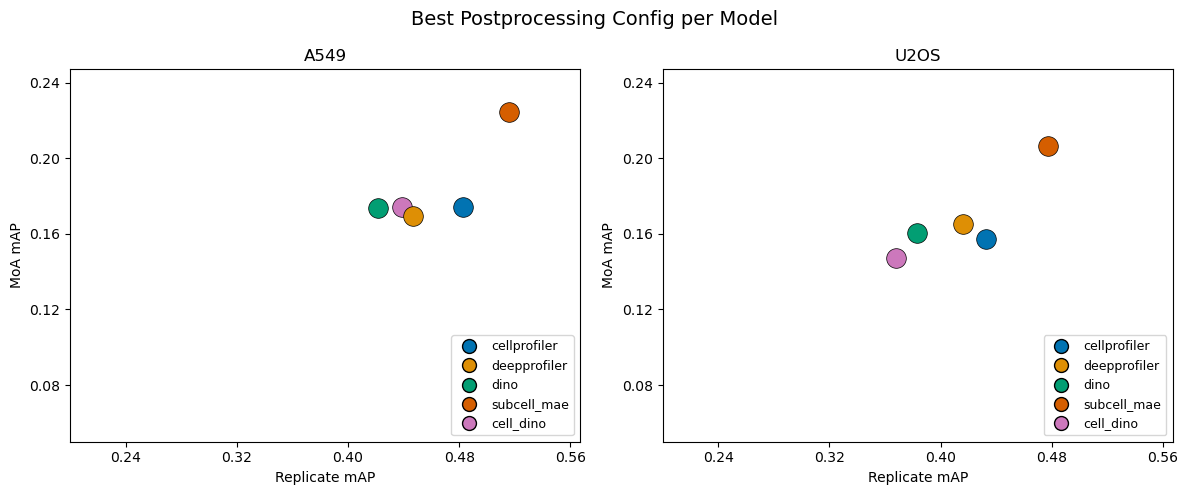

In [8]:
# Seaborn colorblind palette — consistent with per_moa_analysis.ipynb
BEST_MODEL_COLORS = {
    "cellprofiler":       "#0173b2",  # blue
    "deepprofiler":       "#de8f05",  # amber
    "dino":               "#029e73",  # teal
    "subcell_mae":        "#d55e00",  # vermillion
    "cell_dino":          "#cc78bc"   #pink
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
fig.suptitle("Best Postprocessing Config per Model", fontsize=14)

for col_idx, cell_type in enumerate(sorted(selected["cell_type"].unique())):
    ax = axes[0, col_idx]
    ct = selected[selected["cell_type"] == cell_type]

    for _, row in ct.iterrows():
        ax.scatter(row["replicate_mAP"], row["moa_mAP"],
                   c=BEST_MODEL_COLORS[row["model"]], s=200,
                   edgecolors="k", linewidths=0.5, zorder=2)

    ax.set_title(cell_type, fontsize=12)
    ax.set_xlabel("Replicate mAP")
    ax.set_ylabel("MoA mAP")
    ax.set_xlim(0.2, selected["replicate_mAP"].max() * 1.1)
    ax.set_ylim(0.05, selected["moa_mAP"].max() * 1.1)
    ax.xaxis.set_major_locator(plt.MaxNLocator(5))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markeredgecolor="k", markersize=10, label=m)
        for m, c in BEST_MODEL_COLORS.items()
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig("../figures/best_config_scatter.pdf", dpi=300, bbox_inches="tight")
plt.show()

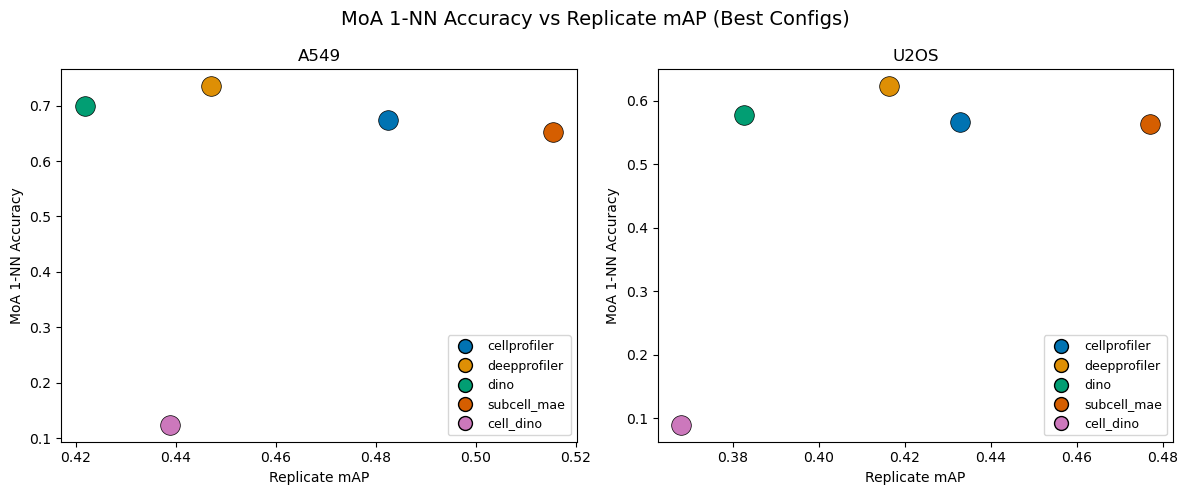

In [9]:
# Scatter: MoA 1-NN Accuracy (y) vs Replicate mAP (x) for best configs
rep_cols = id_cols + ["mAP"]
moa_nn_cols = id_cols + ["nn_k1"]

rep_data = df[df["task"] == "replicate"][rep_cols].rename(columns={"mAP": "replicate_mAP"})
moa_nn_data = df[df["task"] == "moa"][moa_nn_cols].rename(columns={"nn_k1": "moa_nn_k1"})
scatter_data = rep_data.merge(moa_nn_data, on=id_cols)
scatter_data = scatter_data.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MoA 1-NN Accuracy vs Replicate mAP (Best Configs)", fontsize=14)

for col_idx, cell_type in enumerate(sorted(scatter_data["cell_type"].unique())):
    ax = axes[col_idx]
    ct = scatter_data[scatter_data["cell_type"] == cell_type]
    for _, row in ct.iterrows():
        ax.scatter(row["replicate_mAP"], row["moa_nn_k1"],
                   c=BEST_MODEL_COLORS[row["model"]], s=200,
                   edgecolors="k", linewidths=0.5, zorder=2)
    ax.set_title(cell_type, fontsize=12)
    ax.set_xlabel("Replicate mAP")
    ax.set_ylabel("MoA 1-NN Accuracy")

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markeredgecolor="k", markersize=10, label=m)
        for m, c in BEST_MODEL_COLORS.items()
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)

fig.tight_layout()
fig.savefig("../figures/moa_nn_vs_replicate_map.pdf", dpi=300, bbox_inches="tight")
plt.show()

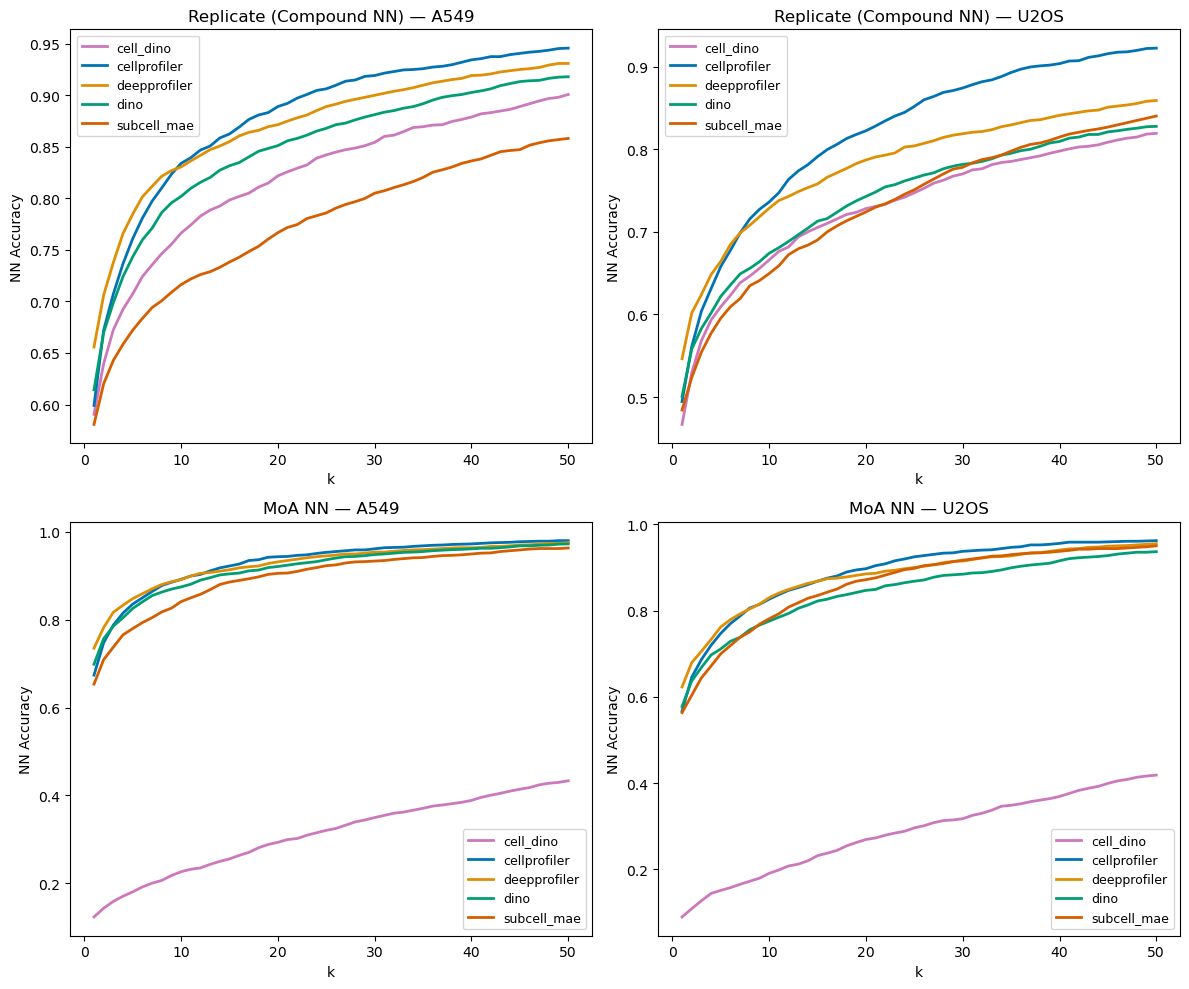

In [10]:
# k-NN accuracy curves (k=1..50) for best configs
# Rows: Replicate (compound NN) / MoA (MoA NN), Columns: cell type
nn_cols = [f"nn_k{k}" for k in range(1, 51)]
ks = np.arange(1, 51)

best_data = df.merge(best_df, on=["model", "agg", "fs", "norm1", "norm2"])
cell_types = sorted(best_data["cell_type"].unique())
task_labels = {"replicate": "Replicate (Compound NN)", "moa": "MoA NN"}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row_idx, task in enumerate(["replicate", "moa"]):
    for col_idx, cell_type in enumerate(cell_types):
        ax = axes[row_idx, col_idx]
        subset = best_data[(best_data["task"] == task) & (best_data["cell_type"] == cell_type)]
        for _, row in subset.iterrows():
            vals = row[nn_cols].values.astype(float)
            ax.plot(ks, vals, color=BEST_MODEL_COLORS[row["model"]],
                    label=row["model"], linewidth=2)
        ax.set_title(f"{task_labels[task]} — {cell_type}", fontsize=12)
        ax.set_xlabel("k")
        ax.set_ylabel("NN Accuracy")
        ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig("../figures/knn_accuracy_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()